In [ ]:
!pip3 install pysimpleautomata
from PySimpleAutomata import automata_IO
# convert a DOT source into graph directly
import graphviz
from IPython.display import display

#https://pysimpleautomata.readthedocs.io/en/latest/tutorial.html

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving inputNFA.txt to inputNFA (3).txt


In [ ]:
for f in uploaded.keys():
    file = open(f, 'r')
    lines = file.readlines()

items=lines[0].strip().split('|')
alphabet=[]
for letter in items[1:]:
  alphabet.append(letter.strip())


In [ ]:
F=[]
NF=[]
Q =[]
q0=''

isQ0inF=False

for line in lines[1:]:
  items=line.strip().split('|')
  state=items[0].strip()
  if state[0] =='-':
   q0=state[1:].strip()
   Q.append(state[1:].strip())

  elif state[0] =='*':
    F.append(state[1:].strip())
    Q.append(state[1:].strip())
  elif state[0] =='+':
    q0=state[1:].strip()
    isQ0inF=True
    F.append(state[1:].strip())
    Q.append(state[1:].strip())
  else:
    Q.append(state.strip())
    NF.append(state.strip())

M=(Q, alphabet, 'delta', q0, F)
print(M)

(['Q0', 'Q1', 'Q2'], ['0', '1'], 'delta', 'Q0', ['Q2'])


In [ ]:
def Delta(qq, a, cells, Q, alphabet):
  s=[]

  for i in range(len(Q)):
    for j in range(len(alphabet)):
      for k in range(len(qq)):
        q=qq[k].strip()

        if q==Q[i] and a==alphabet[j]:
          states=cells[i].strip().split('|')[j+1].split(',')
          if len(states)>0:
            for m in range(len(states)):
              s.append(states[m].strip())
  if '' in s:
    s.remove('')
  if s==[]:
    s=['']
  return s





In [ ]:
cells=lines[1:]

Q1=set(Q)
F1=set(F)
NF1=set(NF)

#delta function
i=0
while i<len(cells):
  for j in range(len(alphabet)):
    line=cells[i].strip().split('|')
    if line[j+1].strip() !='':
      newState=line[j+1].strip()
      states=newState.split(',')


      isFinal=False
      row=''
      for k in range(len(states)):
        stateOut=states[k].strip()

        if stateOut in F:
          F1.add(newState)
          isFinal=True
          row='*'

      if isFinal==False:
        NF1.add(newState)

      if not (newState in Q1):
        Q1.add(newState)
        row+=newState + ' | '

        stateIn=newState.strip().split(',')

        for l in alphabet:
          d=Delta(stateIn, l, cells, Q, alphabet )

          stateOut=set(d)
          if len(stateOut)>0:
            for qq in sorted(stateOut):
              row+=qq + ','
          row=row[:-1]
          row+=' | '

        cells.append('\n'+row)
  i=i+1

newLines=cells

M1=(Q1, alphabet, 'delta', q0, F1)
print('M1=')
print(M1)

print(lines[0])
for r in newLines:
  print(r)



M1=
({'Q0,Q1', 'Q0,Q2', 'Q2', 'Q1', 'Q0'}, ['0', '1'], 'delta', 'Q0', {'Q2', 'Q0,Q2'})
     | 0     |  1 

- Q0 | Q0,Q1 | Q0  

  Q1 |       | Q2  

* Q2 |       | 

Q0,Q1 | Q0,Q1 | Q0,Q2 | 

*Q0,Q2 | Q0,Q1 | Q0 | 


In [ ]:
reachable=dict()
Q1=list(Q1)

for q in Q1:
  reachable[q]=0

reachable[q0]=1

states=[]

line=cells[0].strip().split('|')
for j in range(len(alphabet)):
  if line[j+1].strip() !='':
    state=line[j+1].strip()
    if reachable[state]==0:
     states.append(state)
     reachable[state]=1

while len(states)>0:
  state=states.pop()
  for i in range(1,len(cells)):
    line=cells[i].strip().split('|')
    if line[0].strip() == state:
      for j in range(len(alphabet)):
        if line[j+1].strip() !='':
          state=line[j+1].strip()
          if reachable[state]==0:
            states.append(state)
            reachable[state]=1

print('reachable: ')
print(reachable)

Q2=[]
F2=[]
NF2=[]

for key,value in reachable.items():
  if value==1:
    Q2.append(key)
    if key in F1:
      F2.append(key)
    if key in NF1:
      NF2.append(key)

M2=(Q2, alphabet, 'delta', q0, F2)
print('M2=')
print(M2)


cells2=[]
for i in range(len(newLines)):
  for key, value in reachable.items():
    if newLines[i].strip()[0] in ['-', '+', '*']:
      q=newLines[i].strip()[1:].split("|")[0].strip()
    else:
      q=newLines[i].strip().split("|")[0].strip()

    if key==q and value==1:
      cells2.append(newLines[i])


print(lines[0])
for r in cells2:
  print(r)

reachable: 
{'Q0,Q1': 1, 'Q0,Q2': 1, 'Q2': 0, 'Q1': 0, 'Q0': 1}
M2=
(['Q0,Q1', 'Q0,Q2', 'Q0'], ['0', '1'], 'delta', 'Q0', ['Q0,Q2'])
     | 0     |  1 

- Q0 | Q0,Q1 | Q0  


Q0,Q1 | Q0,Q1 | Q0,Q2 | 

*Q0,Q2 | Q0,Q1 | Q0 | 


In [ ]:
labels=dict()

state='A'
for q in Q2:
  labels[q]=state
  state=chr(ord(state)+1)

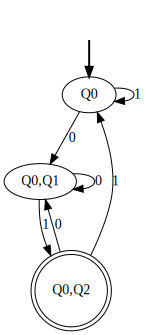

automat
digraph{
    fake [style=invisible]
    fake ->C [style=bold]
C [root=true]
A[label="Q0,Q1"]
C[label="Q0"]
B[shape=doublecircle, label="Q0,Q2"] 
C -> A[label="0"]
C -> C[label="1"]
A -> A[label="0"]
A -> B[label="1"]
B -> A[label="0"]
B -> C[label="1"]
}


In [ ]:

automat='''\
digraph{
    fake [style=invisible]
    fake ->'''
automat=automat+labels[q0]+ ' [style=bold]\n'


automat=automat+labels[q0]+' [root=true]' #+'[label="'+q0+'"]'


for state in NF2:
    #if state != q0:
      automat=automat+'\n'+labels[state] +'[label="'+state+'"]'


for state in F2:
  #if state != q0:
    automat=automat+'\n'+labels[state] +'[shape=doublecircle, label="'+state+'"] '



#delta function
for i in range(len(Q2)):

  for j in range(len(alphabet)):
    line=cells2[i].strip().split('|')
    if (line[j+1].strip() !=''):

      if line[0].strip()[0] in ['-', '+', '*']:
        q=line[0].strip()[1:].strip()
      else:
        q=line[0].strip()
      automat=automat +'\n'+labels[q] +' -> ' + labels[line[j+1].strip()] + '[label="' + alphabet[j] +'"]'



automat=automat+ '\n}'

gvz=graphviz.Source(automat)
display(gvz)

print("automat")
print(automat)

In [ ]:
with open('file.dot', 'w') as out:
  out.write(automat)



data_import = automata_IO.dfa_dot_importer('file.dot')
graphic = automata_IO.dfa_to_dot (data_import, 'output-name', './')